# Ant Colony Optimization for Physical OPM Sensor Selection



Identification of a stable set of physical QSpin OPM sensors for classifying:

- `cue_Left`
- `cue_Right`

Each physical OPM sensor is one selectable unit. Its available X, Y and Z channels remain grouped.



## Scientific distinction

Two results are produced:

1. **Full-data consensus selection** — useful for final ranking, but exploratory.
2. **Nested cross-validation** — ACO runs only inside each outer training fold and provides the defensible generalisation estimate.

Report the nested-CV result as the primary performance result.

## 1. Install compatible packages

In [1]:
%pip install -q --upgrade "mne==1.9.0" "scikit-learn>=1.4,<1.7" joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 37.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 2. Imports and environment

In [2]:
from __future__ import annotations

import gc
import json
import re
import shutil
import sys
import warnings
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Python:", sys.version.split()[0])
print("MNE:", mne.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

try:
    import sklearn
    print("scikit-learn:", sklearn.__version__)
except Exception:
    pass

try:
    import psutil
    memory = psutil.virtual_memory()
    print(
        f"Available RAM: {memory.available / 1024**3:.2f} GiB / "
        f"{memory.total / 1024**3:.2f} GiB"
    )
except Exception:
    print("psutil unavailable; RAM report skipped.")

Python: 3.12.13
MNE: 1.9.0
NumPy: 2.4.6
Pandas: 2.3.3
scikit-learn: 1.6.1
Available RAM: 30.20 GiB / 31.35 GiB


## 3. Configuration

In [3]:
INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working/flux_aco")
EXTRACT_ROOT = WORK_ROOT / "extracted_epochs"
FIGURE_ROOT = WORK_ROOT / "figures"
REPORT_ROOT = WORK_ROOT / "reports"
MODEL_ROOT = WORK_ROOT / "models"
DERIV_ROOT = WORK_ROOT / "derivatives"

for directory in (
    WORK_ROOT, EXTRACT_ROOT, FIGURE_ROOT,
    REPORT_ROOT, MODEL_ROOT, DERIV_ROOT,
):
    directory.mkdir(parents=True, exist_ok=True)

SUBJECT = "01"
SESSION = "01"
TASK = "SpAtt"
RUN = "01"

EPOCHS_FILE_OVERRIDE = None

# First validation run: True. Final 10-run result: False.
QUICK_MODE = True
QUICK_TRIALS_PER_CONDITION = 40

FILTER_L_FREQ_HZ = 1.0
FILTER_H_FREQ_HZ = 30.0
FILTER_ORDER = 4
RESAMPLE_HZ = 100.0

FEATURE_TMIN_S = 0.00
FEATURE_TMAX_S = 0.80
N_TIME_WINDOWS = 8
FEATURE_STATS = ("mean", "std", "rms")

# False keeps incomplete physical sensors with their available axes.
REQUIRE_COMPLETE_XYZ = False

# Arnab Sir's "best 10" requirement.
# Change to 30 or 35 for the reduced-headset experiment.
TARGET_SENSOR_COUNT = 10

ACO_ALPHA = 1.0
ACO_BETA = 2.0
ACO_EVAPORATION = 0.25
ACO_DEPOSIT_SCALE = 1.0
ACO_ELITE_MULTIPLIER = 2.0

QUICK_ACO_ANTS = 6
QUICK_ACO_ITERATIONS = 6
QUICK_ACO_RUNS = 2

FINAL_ACO_ANTS = 20
FINAL_ACO_ITERATIONS = 30
FINAL_ACO_RUNS = 10

REDUNDANCY_WEIGHT = 0.02

SVM_C = 1.0
SVM_CLASS_WEIGHT = None

RANDOM_STATE = 42
QUICK_INNER_SPLITS = 3
FINAL_INNER_SPLITS = 5

RUN_NESTED_CV = True
QUICK_OUTER_SPLITS = 3
FINAL_OUTER_SPLITS = 5

OUTER_N_JOBS = 1
INNER_N_JOBS = 1

CONSENSUS_CV_SPLITS = 5
CONSENSUS_CV_REPEATS = 5

RUN_SENSOR_COUNT_CURVE = False
SENSOR_COUNTS_TO_TEST = [5, 10, 15, 20, 25, 30, 35]
COUNT_CURVE_ANTS = 8
COUNT_CURVE_ITERATIONS = 8

RUN_TIME_RESOLVED_DECODING = True
TIME_DECODING_TMIN_S = -0.10
TIME_DECODING_TMAX_S = 1.00
TIME_DECODING_CV_SPLITS = 5

TOP_SENSORS_FOR_ENERGY_PLOTS = 5
CREATE_DERIVATIVE_ZIP = False

ACO_ANTS = QUICK_ACO_ANTS if QUICK_MODE else FINAL_ACO_ANTS
ACO_ITERATIONS = QUICK_ACO_ITERATIONS if QUICK_MODE else FINAL_ACO_ITERATIONS
ACO_RUNS = QUICK_ACO_RUNS if QUICK_MODE else FINAL_ACO_RUNS
INNER_SPLITS = QUICK_INNER_SPLITS if QUICK_MODE else FINAL_INNER_SPLITS
OUTER_SPLITS = QUICK_OUTER_SPLITS if QUICK_MODE else FINAL_OUTER_SPLITS

print("Quick mode:", QUICK_MODE)
print("Target physical sensors:", TARGET_SENSOR_COUNT)
print("ACO ants / iterations / runs:", ACO_ANTS, ACO_ITERATIONS, ACO_RUNS)

Quick mode: True
Target physical sensors: 10
ACO ants / iterations / runs: 6 6 2


## 4. Locating the condition-specific epoch file

In [4]:
def is_probable_first_split(path):
    name = path.name.casefold()
    if "split-" not in name and not re.search(r"-\d+\.fif$", name):
        return True
    return bool(re.search(r"(?:_|-)split-0*1(?:_|-)", name))


def resolve_override(value, label):
    if value is None:
        return None
    path = Path(value)
    if not path.exists():
        raise FileNotFoundError(f"{label} override does not exist: {path}")
    return path


override = resolve_override(EPOCHS_FILE_OVERRIDE, "Epochs file")

if override is not None:
    epoch_candidates = [override]
else:
    epoch_candidates = [
        path for path in INPUT_ROOT.rglob("*.fif")
        if (
            path.name.casefold().endswith("_epo.fif")
            or "_epo-" in path.name.casefold()
        )
        and is_probable_first_split(path)
    ]

    if not epoch_candidates:
        zip_candidates = [
            path for path in INPUT_ROOT.rglob("*.zip")
            if (
                "epoch" in path.name.casefold()
                or "condition" in path.name.casefold()
            )
            and "figure" not in path.name.casefold()
            and "report" not in path.name.casefold()
        ]

        for index, archive_path in enumerate(zip_candidates):
            destination = EXTRACT_ROOT / f"archive_{index:02d}_{archive_path.stem}"
            destination.mkdir(parents=True, exist_ok=True)
            print("Extracting:", archive_path)
            with zipfile.ZipFile(archive_path, "r") as archive:
                archive.extractall(destination)

        epoch_candidates = [
            path for path in EXTRACT_ROOT.rglob("*.fif")
            if (
                path.name.casefold().endswith("_epo.fif")
                or "_epo-" in path.name.casefold()
            )
            and is_probable_first_split(path)
        ]

    epoch_candidates = sorted(
        epoch_candidates,
        key=lambda path: (
            int("quick" not in path.name.casefold() and "test" not in path.name.casefold()),
            int("desc-cue" in path.name.casefold()),
            int("analysis" in str(path).casefold()),
            str(path),
        ),
        reverse=True,
    )

if not epoch_candidates:
    raise FileNotFoundError(
        "No condition-specific epoch FIF was found under /kaggle/input."
    )

print("Epoch candidates:")
for index, path in enumerate(epoch_candidates[:20]):
    print(f"  [{index}] {path}")

EPOCHS_FILE = epoch_candidates[0]
print("\nSelected epoch file:", EPOCHS_FILE)

Epoch candidates:
  [0] /kaggle/input/datasets/srijanroysr10/cercaoxf/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif

Selected epoch file: /kaggle/input/datasets/srijanroysr10/cercaoxf/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif


## 5. Epoch-Reading

In [5]:
epochs = mne.read_epochs(
    EPOCHS_FILE,
    proj=False,
    preload=True,
    verbose=True,
)

print(epochs)
print("Conditions:", epochs.event_id)
print("Channels:", len(epochs.ch_names))
print("Sampling frequency:", epochs.info["sfreq"])
print("Epoch interval:", (epochs.tmin, epochs.tmax))
print("Bad channels:", epochs.info.get("bads", []))

condition_count_df = pd.DataFrame(
    [
        {"condition": condition, "epochs": len(epochs[condition])}
        for condition in epochs.event_id
    ]
).sort_values("condition")

display(condition_count_df)
condition_count_df.to_csv(
    REPORT_ROOT / "input_condition_counts.csv",
    index=False,
)

Reading /kaggle/input/datasets/srijanroysr10/cercaoxf/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif ...
    Read a total of 8 projection items:
        HFC: l=1 m=-1 (1 x 180) active
        HFC: l=1 m=0 (1 x 180) active
        HFC: l=1 m=1 (1 x 180) active
        HFC: l=2 m=-2 (1 x 180) active
        HFC: l=2 m=-1 (1 x 180) active
        HFC: l=2 m=0 (1 x 180) active
        HFC: l=2 m=1 (1 x 180) active
        HFC: l=2 m=2 (1 x 180) active
    Found the data of interest:
        t =    -749.33 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
219 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 8)
<EpochsFIF | 219 events (all good), -0.749 – 2 s (baseline off), ~719.1 MiB, data loaded,
 'cue_Left': 113
 'cue_Right': 106>
Conditions: {'cue_Left': 5, 'cue_Right': 6}
Channels: 207
Sampling frequency: 750.0
Epoch interval: (np.float64(-0

,condition,epochs
0,cue_Left,113
1,cue_Right,106


## 6. cue-left and cue-right conditions

In [6]:
def normalise_condition_name(name):
    return "_".join(re.findall(r"[a-z0-9]+", str(name).casefold()))


def identify_condition(event_id, direction):
    matches = []
    for condition_name in event_id:
        normalised = normalise_condition_name(condition_name)
        tokens = set(normalised.split("_"))
        if (
            ("cue" in tokens or normalised.startswith("cue"))
            and direction.casefold() in tokens
        ):
            matches.append(condition_name)

    if len(matches) != 1:
        raise ValueError(
            f"Expected one cue-{direction} condition, found {matches}. "
            f"Available: {event_id}"
        )
    return matches[0]


left_condition = identify_condition(epochs.event_id, "left")
right_condition = identify_condition(epochs.event_id, "right")

print("Cue-left:", left_condition, len(epochs[left_condition]))
print("Cue-right:", right_condition, len(epochs[right_condition]))

Cue-left: cue_Left 113
Cue-right: cue_Right 106


## 7. Channel Mapping

In [7]:
_AXIS_PATTERN = re.compile(
    r"(?:^|[\s_-])([XYZ])$",
    flags=re.IGNORECASE,
)


def infer_axis(channel_name):
    match = _AXIS_PATTERN.search(channel_name.strip())
    if match:
        return match.group(1).upper()
    if channel_name and channel_name.strip()[-1].upper() in {"X", "Y", "Z"}:
        return channel_name.strip()[-1].upper()
    return None


def physical_sensor_name(channel_name):
    name = re.sub(
        r"(?:[\s_-]+)[XYZ]$",
        "",
        channel_name.strip(),
        flags=re.IGNORECASE,
    )
    return re.sub(r"\s+", " ", name).strip()


good_mag_names = [
    name
    for name, channel_type in zip(
        epochs.ch_names,
        epochs.get_channel_types(),
    )
    if channel_type == "mag"
    and name not in epochs.info.get("bads", [])
]

sensor_to_channels = defaultdict(list)

for channel_name in good_mag_names:
    axis = infer_axis(channel_name)
    if axis is not None:
        sensor_to_channels[
            physical_sensor_name(channel_name)
        ].append(channel_name)

sensor_rows = []

for sensor_name, channels in sorted(sensor_to_channels.items()):
    axes = sorted(
        axis
        for axis in (infer_axis(channel) for channel in channels)
        if axis is not None
    )

    sensor_rows.append(
        {
            "physical_sensor": sensor_name,
            "n_channels": len(channels),
            "axes": ",".join(axes),
            "complete_xyz": set(axes) == {"X", "Y", "Z"},
            "channels": "|".join(channels),
        }
    )

sensor_inventory_df = pd.DataFrame(sensor_rows)

if REQUIRE_COMPLETE_XYZ:
    retained_sensor_names = sensor_inventory_df.loc[
        sensor_inventory_df["complete_xyz"],
        "physical_sensor",
    ].tolist()
else:
    retained_sensor_names = sensor_inventory_df["physical_sensor"].tolist()

sensor_inventory_df["retained_for_aco"] = sensor_inventory_df[
    "physical_sensor"
].isin(retained_sensor_names)

display(sensor_inventory_df)

sensor_inventory_df.to_csv(
    REPORT_ROOT / "physical_sensor_inventory.csv",
    index=False,
)

print("Good magnetometer channels:", len(good_mag_names))
print("Physical sensors discovered:", len(sensor_inventory_df))
print("Physical sensors retained:", len(retained_sensor_names))

if TARGET_SENSOR_COUNT > len(retained_sensor_names):
    raise ValueError(
        "TARGET_SENSOR_COUNT exceeds the available physical-sensor count."
    )

,physical_sensor,n_channels,axes,complete_xyz,channels,retained_for_aco
0,C1 A7,3,"X,Y,Z",True,C1 A7 Z|C1 A7 Y|C1 A7 X,True
1,C2 B5,3,"X,Y,Z",True,C2 B5 Z|C2 B5 Y|C2 B5 X,True
2,C3 C2,3,"X,Y,Z",True,C3 C2 Z|C3 C2 Y|C3 C2 X,True
3,C4 D7,3,"X,Y,Z",True,C4 D7 Z|C4 D7 Y|C4 D7 X,True
4,C5 C1,3,"X,Y,Z",True,C5 C1 Z|C5 C1 Y|C5 C1 X,True
...,...,...,...,...,...,...
57,T5 C5,1,X,False,T5 C5 X,True
58,T6 D6,3,"X,Y,Z",True,T6 D6 Z|T6 D6 Y|T6 D6 X,True
59,T7 C8,3,"X,Y,Z",True,T7 C8 Z|T7 C8 Y|T7 C8 X,True
60,T8 D2,3,"X,Y,Z",True,T8 D2 Z|T8 D2 Y|T8 D2 X,True


Good magnetometer channels: 180
Physical sensors discovered: 62
Physical sensors retained: 62


## 8. Prepare filtered and resampled sensor data

In [8]:
selected_channel_names = []

for sensor_name in retained_sensor_names:
    selected_channel_names.extend(sensor_to_channels[sensor_name])

epochs_signal = epochs.copy().pick(selected_channel_names)


def select_evenly_spaced(condition_epochs, requested_count):
    if requested_count >= len(condition_epochs):
        return condition_epochs

    indices = np.unique(
        np.linspace(
            0,
            len(condition_epochs) - 1,
            requested_count,
        ).round().astype(int)
    )
    return condition_epochs[indices]


if QUICK_MODE:
    left_epochs = select_evenly_spaced(
        epochs_signal[left_condition],
        QUICK_TRIALS_PER_CONDITION,
    )
    right_epochs = select_evenly_spaced(
        epochs_signal[right_condition],
        QUICK_TRIALS_PER_CONDITION,
    )
else:
    left_epochs = epochs_signal[left_condition]
    right_epochs = epochs_signal[right_condition]

epochs_signal = mne.concatenate_epochs(
    [left_epochs, right_epochs],
    add_offset=True,
    on_mismatch="raise",
    verbose=False,
)

y = np.concatenate(
    [
        np.zeros(len(left_epochs), dtype=int),
        np.ones(len(right_epochs), dtype=int),
    ]
)

iir_params = {
    "order": FILTER_ORDER,
    "ftype": "butter",
    "output": "sos",
}

epochs_signal.filter(
    l_freq=FILTER_L_FREQ_HZ,
    h_freq=FILTER_H_FREQ_HZ,
    picks="mag",
    method="iir",
    iir_params=iir_params,
    phase="zero",
    verbose=True,
)

epochs_signal.resample(
    RESAMPLE_HZ,
    npad="auto",
    verbose=True,
)

if FEATURE_TMIN_S < epochs_signal.tmin or FEATURE_TMAX_S > epochs_signal.tmax:
    raise ValueError(
        "Configured feature interval lies outside the available epoch."
    )

X_signal = epochs_signal.get_data(copy=True)
signal_times = epochs_signal.times.copy()
signal_channel_names = list(epochs_signal.ch_names)

print("Signal matrix:", X_signal.shape)
print("Labels:", np.bincount(y, minlength=2))

Setting up band-pass filter from 1 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 30.00 Hz: -6.02, -6.02 dB

Signal matrix: (80, 180, 275)
Labels: [40 40]


## 9. Extract windowed physical-sensor energy features

In [9]:
window_edges = np.linspace(
    FEATURE_TMIN_S,
    FEATURE_TMAX_S,
    N_TIME_WINDOWS + 1,
)

channel_index = {
    channel_name: index
    for index, channel_name in enumerate(signal_channel_names)
}

feature_blocks = []
feature_names = []
sensor_feature_columns = {}
column_start = 0

for sensor_name in retained_sensor_names:
    sensor_channels = [
        channel
        for channel in sensor_to_channels[sensor_name]
        if channel in channel_index
    ]

    sensor_indices = [
        channel_index[channel]
        for channel in sensor_channels
    ]

    sensor_data = X_signal[:, sensor_indices, :]
    sensor_features = []
    sensor_feature_names = []

    for window_index in range(N_TIME_WINDOWS):
        tmin = window_edges[window_index]
        tmax = window_edges[window_index + 1]

        if window_index == N_TIME_WINDOWS - 1:
            time_mask = (signal_times >= tmin) & (signal_times <= tmax)
        else:
            time_mask = (signal_times >= tmin) & (signal_times < tmax)

        if not np.any(time_mask):
            raise ValueError(f"No samples in feature window {tmin}–{tmax} s.")

        window_data = sensor_data[:, :, time_mask]

        for local_index, channel_name in enumerate(sensor_channels):
            axis = infer_axis(channel_name)
            axis_data = window_data[:, local_index, :]

            if "mean" in FEATURE_STATS:
                sensor_features.append(np.mean(axis_data, axis=1))
                sensor_feature_names.append(
                    f"{sensor_name}|{axis}|w{window_index}|mean"
                )

            if "std" in FEATURE_STATS:
                sensor_features.append(np.std(axis_data, axis=1))
                sensor_feature_names.append(
                    f"{sensor_name}|{axis}|w{window_index}|std"
                )

            if "rms" in FEATURE_STATS:
                sensor_features.append(
                    np.sqrt(np.mean(axis_data**2, axis=1))
                )
                sensor_feature_names.append(
                    f"{sensor_name}|{axis}|w{window_index}|rms"
                )

        pooled_rms = np.sqrt(
            np.mean(window_data**2, axis=(1, 2))
        )
        sensor_features.append(pooled_rms)
        sensor_feature_names.append(
            f"{sensor_name}|pooled|w{window_index}|rms"
        )

    sensor_block = np.column_stack(sensor_features)
    feature_blocks.append(sensor_block)
    feature_names.extend(sensor_feature_names)

    column_stop = column_start + sensor_block.shape[1]
    sensor_feature_columns[sensor_name] = np.arange(
        column_start,
        column_stop,
        dtype=int,
    )
    column_start = column_stop

X_features = np.concatenate(feature_blocks, axis=1)

pd.DataFrame(
    {
        "feature_index": np.arange(len(feature_names)),
        "feature_name": feature_names,
    }
).to_csv(
    REPORT_ROOT / "feature_metadata.csv",
    index=False,
)

print("Feature matrix:", X_features.shape)

Feature matrix: (80, 4816)


## 10. Classifier and scoring helpers

In [10]:
def make_classifier():
    return make_pipeline(
        StandardScaler(),
        SVC(
            kernel="linear",
            C=SVM_C,
            class_weight=SVM_CLASS_WEIGHT,
        ),
    )


def subset_columns(sensor_subset, sensor_columns):
    columns = np.concatenate(
        [sensor_columns[sensor_name] for sensor_name in sensor_subset]
    )
    return np.asarray(sorted(columns.tolist()), dtype=int)


def cv_auc_for_subset(
    X,
    y_values,
    sensor_subset,
    sensor_columns,
    cv_splits,
):
    columns = subset_columns(sensor_subset, sensor_columns)

    scores = cross_val_score(
        make_classifier(),
        X[:, columns],
        y_values,
        cv=cv_splits,
        scoring="roc_auc",
        n_jobs=INNER_N_JOBS,
    )

    return float(np.mean(scores)), float(np.std(scores))

## 11. Calculate univariate sensor heuristics

In [11]:
def compute_sensor_heuristics(
    X,
    y_values,
    sensor_names,
    sensor_columns,
    n_splits,
    seed,
):
    effective_splits = min(
        n_splits,
        int(np.min(np.bincount(y_values))),
    )

    cv = StratifiedKFold(
        n_splits=effective_splits,
        shuffle=True,
        random_state=seed,
    )

    cv_splits = list(cv.split(X, y_values))
    rows = []

    for sensor_name in sensor_names:
        mean_auc, std_auc = cv_auc_for_subset(
            X,
            y_values,
            (sensor_name,),
            sensor_columns,
            cv_splits,
        )

        rows.append(
            {
                "physical_sensor": sensor_name,
                "univariate_mean_auc": mean_auc,
                "univariate_std_auc": std_auc,
            }
        )

    heuristic_df = pd.DataFrame(rows)

    raw_heuristic = np.maximum(
        heuristic_df["univariate_mean_auc"].to_numpy() - 0.5,
        0.0,
    )

    heuristic = raw_heuristic + 0.01
    heuristic = heuristic / np.mean(heuristic)

    heuristic_df["aco_heuristic"] = heuristic

    return heuristic, heuristic_df


full_heuristic, univariate_df = compute_sensor_heuristics(
    X_features,
    y,
    retained_sensor_names,
    sensor_feature_columns,
    INNER_SPLITS,
    RANDOM_STATE,
)

univariate_df = univariate_df.sort_values(
    "univariate_mean_auc",
    ascending=False,
).reset_index(drop=True)

display(univariate_df.head(20))

univariate_df.to_csv(
    REPORT_ROOT / "univariate_sensor_heuristics.csv",
    index=False,
)

,physical_sensor,univariate_mean_auc,univariate_std_auc,aco_heuristic
0,O2 H3,0.747112,0.054550,4.081145
1,Fpz A2,0.671175,0.153205,2.875796
2,T3 C4,0.656805,0.053997,2.647697
3,F9 A4,0.650465,0.053803,2.547065
4,F8 B1,0.645393,0.002263,2.466559
5,F10 B3,0.632291,0.062810,2.258586
6,Fz A5,0.631586,0.124954,2.247405
7,T13 G8,0.628487,0.055753,2.198207
8,P7 E7,0.615526,0.092059,1.992470
9,O1 E5,0.609890,0.085944,1.903020


## 12. Precompute sensor redundancy

In [12]:
def compute_sensor_redundancy(X, sensor_names, sensor_columns):
    summaries = []

    for sensor_name in sensor_names:
        block = X[:, sensor_columns[sensor_name]]

        block_mean = np.mean(block, axis=0, keepdims=True)
        block_std = np.std(block, axis=0, keepdims=True)
        block_std = np.where(block_std > 0, block_std, 1.0)

        standardised = (block - block_mean) / block_std

        summaries.append(
            np.mean(np.abs(standardised), axis=1)
        )

    summary_matrix = np.column_stack(summaries)

    redundancy = np.abs(
        np.corrcoef(summary_matrix, rowvar=False)
    )

    redundancy = np.nan_to_num(
        redundancy,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    np.fill_diagonal(redundancy, 0.0)
    return redundancy


full_redundancy = compute_sensor_redundancy(
    X_features,
    retained_sensor_names,
    sensor_feature_columns,
)

pd.DataFrame(
    full_redundancy,
    index=retained_sensor_names,
    columns=retained_sensor_names,
).to_csv(
    REPORT_ROOT / "sensor_redundancy_matrix.csv",
)

print("Redundancy matrix:", full_redundancy.shape)

Redundancy matrix: (62, 62)


## 13. Custom ACO implementation

In [13]:
@dataclass
class ACOResult:
    best_subset: tuple
    best_fitness: float
    best_auc: float
    best_redundancy: float
    convergence: list
    evaluated_subsets: int
    final_pheromone: np.ndarray


def subset_redundancy(subset_indices, redundancy_matrix):
    if len(subset_indices) < 2:
        return 0.0

    submatrix = redundancy_matrix[
        np.ix_(subset_indices, subset_indices)
    ]

    upper = submatrix[
        np.triu_indices(len(subset_indices), k=1)
    ]

    return float(np.mean(upper))


def construct_ant_subset(
    pheromone,
    heuristic,
    subset_size,
    rng,
):
    available = list(range(len(pheromone)))
    selected = []

    for _ in range(subset_size):
        available_array = np.asarray(available, dtype=int)

        desirability = (
            np.power(pheromone[available_array], ACO_ALPHA)
            * np.power(heuristic[available_array], ACO_BETA)
        )

        if (
            not np.all(np.isfinite(desirability))
            or np.sum(desirability) <= 0
        ):
            probabilities = np.full(
                len(available_array),
                1.0 / len(available_array),
            )
        else:
            probabilities = desirability / np.sum(desirability)

        selected_index = int(
            rng.choice(available_array, p=probabilities)
        )

        selected.append(selected_index)
        available.remove(selected_index)

    return tuple(sorted(selected))


def run_aco(
    X,
    y_values,
    sensor_names,
    sensor_columns,
    heuristic,
    redundancy_matrix,
    subset_size,
    ants,
    iterations,
    inner_splits,
    seed,
):
    rng = np.random.default_rng(seed)

    effective_splits = min(
        inner_splits,
        int(np.min(np.bincount(y_values))),
    )

    cv = StratifiedKFold(
        n_splits=effective_splits,
        shuffle=True,
        random_state=seed,
    )

    cv_splits = list(cv.split(X, y_values))
    pheromone = np.ones(len(sensor_names), dtype=float)
    fitness_cache = {}

    best_subset_indices = None
    best_fitness = -np.inf
    best_auc = np.nan
    best_redundancy = np.nan
    convergence = []

    def evaluate(subset_indices):
        if subset_indices in fitness_cache:
            return fitness_cache[subset_indices]

        subset_names = tuple(
            sensor_names[index]
            for index in subset_indices
        )

        mean_auc, _ = cv_auc_for_subset(
            X,
            y_values,
            subset_names,
            sensor_columns,
            cv_splits,
        )

        redundancy_value = subset_redundancy(
            subset_indices,
            redundancy_matrix,
        )

        fitness = mean_auc - REDUNDANCY_WEIGHT * redundancy_value

        result = (
            float(fitness),
            float(mean_auc),
            float(redundancy_value),
        )

        fitness_cache[subset_indices] = result
        return result

    for _ in range(iterations):
        ant_results = []

        for _ in range(ants):
            subset_indices = construct_ant_subset(
                pheromone,
                heuristic,
                subset_size,
                rng,
            )

            fitness, mean_auc, redundancy_value = evaluate(
                subset_indices
            )

            ant_results.append(
                (
                    subset_indices,
                    fitness,
                    mean_auc,
                    redundancy_value,
                )
            )

            if fitness > best_fitness:
                best_subset_indices = subset_indices
                best_fitness = fitness
                best_auc = mean_auc
                best_redundancy = redundancy_value

        pheromone *= (1.0 - ACO_EVAPORATION)

        for subset_indices, fitness, _, _ in ant_results:
            deposit = (
                ACO_DEPOSIT_SCALE
                * max(fitness - 0.5, 1e-6)
            )
            pheromone[list(subset_indices)] += deposit

        if best_subset_indices is not None:
            elite_deposit = (
                ACO_ELITE_MULTIPLIER
                * ACO_DEPOSIT_SCALE
                * max(best_fitness - 0.5, 1e-6)
            )
            pheromone[list(best_subset_indices)] += elite_deposit

        pheromone = np.clip(pheromone, 1e-6, 1e6)
        convergence.append(float(best_auc))

    if best_subset_indices is None:
        raise RuntimeError("ACO did not evaluate a sensor subset.")

    return ACOResult(
        best_subset=tuple(
            sensor_names[index]
            for index in best_subset_indices
        ),
        best_fitness=float(best_fitness),
        best_auc=float(best_auc),
        best_redundancy=float(best_redundancy),
        convergence=convergence,
        evaluated_subsets=len(fitness_cache),
        final_pheromone=pheromone.copy(),
    )

## 14. Repeated ACO searches

In [14]:
full_run_results = []
convergence_rows = []
selection_counter = Counter()
pheromone_accumulator = np.zeros(
    len(retained_sensor_names),
    dtype=float,
)

for run_index in range(ACO_RUNS):
    seed = RANDOM_STATE + run_index

    print(f"ACO run {run_index + 1}/{ACO_RUNS}, seed={seed}")

    result = run_aco(
        X_features,
        y,
        retained_sensor_names,
        sensor_feature_columns,
        full_heuristic,
        full_redundancy,
        TARGET_SENSOR_COUNT,
        ACO_ANTS,
        ACO_ITERATIONS,
        INNER_SPLITS,
        seed,
    )

    selection_counter.update(result.best_subset)

    pheromone_accumulator += (
        result.final_pheromone
        / np.mean(result.final_pheromone)
    )

    full_run_results.append(
        {
            "run": run_index + 1,
            "seed": seed,
            "best_auc": result.best_auc,
            "best_fitness": result.best_fitness,
            "best_redundancy": result.best_redundancy,
            "evaluated_subsets": result.evaluated_subsets,
            "selected_sensors": "|".join(result.best_subset),
        }
    )

    for iteration_index, best_auc in enumerate(
        result.convergence,
        start=1,
    ):
        convergence_rows.append(
            {
                "run": run_index + 1,
                "iteration": iteration_index,
                "best_auc": best_auc,
            }
        )

    print("  best AUC:", f"{result.best_auc:.4f}")
    print("  sensors:", result.best_subset)

full_run_df = pd.DataFrame(full_run_results)
convergence_df = pd.DataFrame(convergence_rows)

display(full_run_df)

full_run_df.to_csv(
    REPORT_ROOT / "aco_repeated_runs.csv",
    index=False,
)

convergence_df.to_csv(
    REPORT_ROOT / "aco_convergence.csv",
    index=False,
)

ACO run 1/2, seed=42
  best AUC: 0.8121
  sensors: ('F8 B1', 'Fpz A2', 'Fz A5', 'O1 E5', 'O2 H3', 'O3 G6', 'O9 G3', 'P4 D3', 'T11 G7', 'T13 G8')
ACO run 2/2, seed=43
  best AUC: 0.7782
  sensors: ('Cz E2', 'F10 B3', 'F3 A3', 'F9 A4', 'Fpz A2', 'Fz A5', 'O1 E5', 'O2 H3', 'P10 F5', 'P7 E7')


,run,seed,best_auc,best_fitness,best_redundancy,evaluated_subsets,selected_sensors
0,1,42,0.812060,0.802645,0.470760,36,F8 B1|Fpz A2|Fz A5|O1 E5|O2 H3|O3 G6|O9 G3|P4 ...
1,2,43,0.778247,0.769912,0.416746,36,Cz E2|F10 B3|F3 A3|F9 A4|Fpz A2|Fz A5|O1 E5|O2...


## 15. Stable consensus sensor ranking

In [15]:
heuristic_lookup = (
    univariate_df.set_index("physical_sensor")[
        "univariate_mean_auc"
    ].to_dict()
)

consensus_rows = []

for sensor_index, sensor_name in enumerate(retained_sensor_names):
    axes = sorted(
        infer_axis(channel)
        for channel in sensor_to_channels[sensor_name]
    )

    consensus_rows.append(
        {
            "physical_sensor": sensor_name,
            "selection_count": int(
                selection_counter[sensor_name]
            ),
            "selection_frequency": float(
                selection_counter[sensor_name] / ACO_RUNS
            ),
            "mean_normalised_pheromone": float(
                pheromone_accumulator[sensor_index] / ACO_RUNS
            ),
            "univariate_auc": float(
                heuristic_lookup[sensor_name]
            ),
            "n_axes": len(axes),
            "axes": ",".join(axes),
        }
    )

consensus_ranking_df = pd.DataFrame(
    consensus_rows
).sort_values(
    [
        "selection_count",
        "mean_normalised_pheromone",
        "univariate_auc",
    ],
    ascending=[False, False, False],
).reset_index(drop=True)

consensus_ranking_df.insert(
    0,
    "consensus_rank",
    np.arange(1, len(consensus_ranking_df) + 1),
)

consensus_sensor_subset = tuple(
    consensus_ranking_df.head(
        TARGET_SENSOR_COUNT
    )["physical_sensor"].tolist()
)

display(
    consensus_ranking_df.head(
        max(TARGET_SENSOR_COUNT, 20)
    )
)

print("Consensus subset:")
for rank, sensor_name in enumerate(
    consensus_sensor_subset,
    start=1,
):
    print(f"  {rank:>2}. {sensor_name}")

consensus_ranking_df.to_csv(
    REPORT_ROOT / "aco_consensus_sensor_ranking.csv",
    index=False,
)

(
    REPORT_ROOT / "aco_consensus_sensor_subset.json"
).write_text(
    json.dumps(
        {
            "target_sensor_count": TARGET_SENSOR_COUNT,
            "sensors": list(consensus_sensor_subset),
        },
        indent=2,
    ),
    encoding="utf-8",
)

,consensus_rank,physical_sensor,selection_count,selection_frequency,mean_normalised_pheromone,univariate_auc,n_axes,axes
0,1,O2 H3,2,1.0,5.351840,0.747112,2,"X,Z"
1,2,Fpz A2,2,1.0,4.165029,0.671175,3,"X,Y,Z"
2,3,Fz A5,2,1.0,4.060192,0.631586,3,"X,Y,Z"
3,4,O1 E5,2,1.0,3.955619,0.609890,3,"X,Y,Z"
4,5,F9 A4,1,0.5,4.130827,0.650465,3,"X,Y,Z"
5,6,F10 B3,1,0.5,3.837678,0.632291,3,"X,Y,Z"
6,7,F8 B1,1,0.5,3.723851,0.645393,3,"X,Y,Z"
7,8,O3 G6,1,0.5,2.677101,0.609608,3,"X,Y,Z"
8,9,T13 G8,1,0.5,2.604337,0.628487,3,"X,Y,Z"
9,10,P7 E7,1,0.5,2.549147,0.615526,3,"X,Y,Z"


Consensus subset:
   1. O2 H3
   2. Fpz A2
   3. Fz A5
   4. O1 E5
   5. F9 A4
   6. F10 B3
   7. F8 B1
   8. O3 G6
   9. T13 G8
  10. P7 E7


183

## 16. Plot convergence and stability

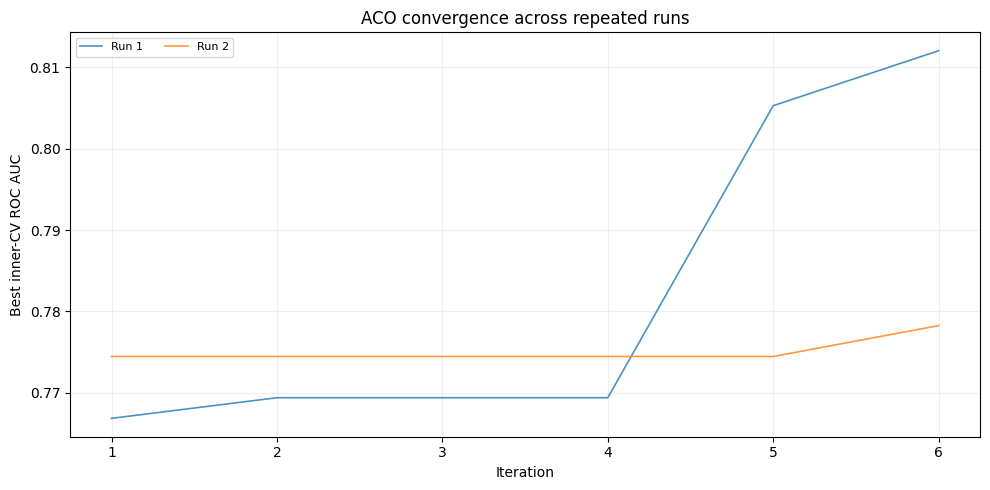

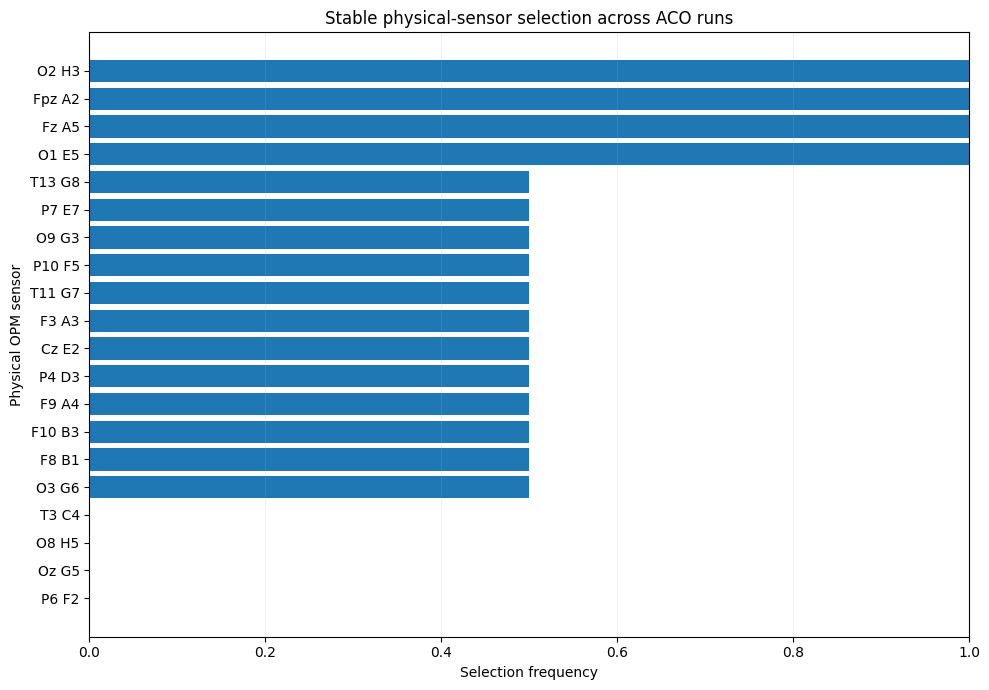

Saved: /kaggle/working/flux_aco/figures/aco_convergence.png
Saved: /kaggle/working/flux_aco/figures/aco_sensor_selection_stability.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

for run_index, run_df in convergence_df.groupby("run"):
    ax.plot(
        run_df["iteration"],
        run_df["best_auc"],
        linewidth=1.2,
        alpha=0.8,
        label=f"Run {run_index}",
    )

ax.set(
    title="ACO convergence across repeated runs",
    xlabel="Iteration",
    ylabel="Best inner-CV ROC AUC",
)
ax.grid(alpha=0.2)

if ACO_RUNS <= 10:
    ax.legend(fontsize=8, ncol=2)

fig.tight_layout()

convergence_figure = FIGURE_ROOT / "aco_convergence.png"

fig.savefig(
    convergence_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

top_plot_df = consensus_ranking_df.head(
    min(20, len(consensus_ranking_df))
).sort_values("selection_frequency")

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_plot_df["physical_sensor"],
    top_plot_df["selection_frequency"],
)

ax.set(
    title="Stable physical-sensor selection across ACO runs",
    xlabel="Selection frequency",
    ylabel="Physical OPM sensor",
    xlim=(0, 1),
)
ax.grid(axis="x", alpha=0.2)

fig.tight_layout()

stability_figure = FIGURE_ROOT / "aco_sensor_selection_stability.png"

fig.savefig(
    stability_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("Saved:", convergence_figure)
print("Saved:", stability_figure)

## 17. Exploratory consensus versus all-sensor baseline

In [17]:
consensus_cv = RepeatedStratifiedKFold(
    n_splits=min(
        CONSENSUS_CV_SPLITS,
        int(np.min(np.bincount(y))),
    ),
    n_repeats=CONSENSUS_CV_REPEATS,
    random_state=RANDOM_STATE,
)

consensus_columns = subset_columns(
    consensus_sensor_subset,
    sensor_feature_columns,
)

all_sensor_subset = tuple(retained_sensor_names)

all_columns = subset_columns(
    all_sensor_subset,
    sensor_feature_columns,
)

consensus_scores = cross_val_score(
    make_classifier(),
    X_features[:, consensus_columns],
    y,
    cv=consensus_cv,
    scoring="roc_auc",
    n_jobs=OUTER_N_JOBS,
)

all_sensor_scores = cross_val_score(
    make_classifier(),
    X_features[:, all_columns],
    y,
    cv=consensus_cv,
    scoring="roc_auc",
    n_jobs=OUTER_N_JOBS,
)

exploratory_comparison_df = pd.DataFrame(
    [
        {
            "sensor_set": "ACO consensus",
            "n_physical_sensors": len(consensus_sensor_subset),
            "mean_auc": float(np.mean(consensus_scores)),
            "std_auc": float(np.std(consensus_scores)),
            "n_cv_scores": len(consensus_scores),
            "interpretation": "exploratory_full_data_selection",
        },
        {
            "sensor_set": "All physical sensors",
            "n_physical_sensors": len(retained_sensor_names),
            "mean_auc": float(np.mean(all_sensor_scores)),
            "std_auc": float(np.std(all_sensor_scores)),
            "n_cv_scores": len(all_sensor_scores),
            "interpretation": "baseline",
        },
    ]
)

display(exploratory_comparison_df)

exploratory_comparison_df.to_csv(
    REPORT_ROOT / "exploratory_consensus_vs_all_sensors.csv",
    index=False,
)

,sensor_set,n_physical_sensors,mean_auc,std_auc,n_cv_scores,interpretation
0,ACO consensus,10,0.738750,0.116803,25,exploratory_full_data_selection
1,All physical sensors,62,0.624375,0.131731,25,baseline


## 18. Leakage-safe nested cross-validation

In [18]:
nested_fold_rows = []
nested_prediction_rows = []
nested_selection_counter = Counter()

if RUN_NESTED_CV:
    effective_outer_splits = min(
        OUTER_SPLITS,
        int(np.min(np.bincount(y))),
    )

    outer_cv = StratifiedKFold(
        n_splits=effective_outer_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    for fold_index, (train_indices, test_indices) in enumerate(
        outer_cv.split(X_features, y),
        start=1,
    ):
        print(
            f"Nested outer fold {fold_index}/{effective_outer_splits}"
        )

        X_train = X_features[train_indices]
        y_train = y[train_indices]
        X_test = X_features[test_indices]
        y_test = y[test_indices]

        fold_heuristic, _ = compute_sensor_heuristics(
            X_train,
            y_train,
            retained_sensor_names,
            sensor_feature_columns,
            INNER_SPLITS,
            RANDOM_STATE + 1000 + fold_index,
        )

        fold_redundancy = compute_sensor_redundancy(
            X_train,
            retained_sensor_names,
            sensor_feature_columns,
        )

        fold_result = run_aco(
            X_train,
            y_train,
            retained_sensor_names,
            sensor_feature_columns,
            fold_heuristic,
            fold_redundancy,
            TARGET_SENSOR_COUNT,
            ACO_ANTS,
            ACO_ITERATIONS,
            INNER_SPLITS,
            RANDOM_STATE + 2000 + fold_index,
        )

        nested_selection_counter.update(
            fold_result.best_subset
        )

        fold_columns = subset_columns(
            fold_result.best_subset,
            sensor_feature_columns,
        )

        fold_model = make_classifier()
        fold_model.fit(
            X_train[:, fold_columns],
            y_train,
        )

        decision_scores = fold_model.decision_function(
            X_test[:, fold_columns]
        )
        predictions = (decision_scores >= 0.0).astype(int)

        fold_auc = roc_auc_score(y_test, decision_scores)

        nested_fold_rows.append(
            {
                "outer_fold": fold_index,
                "test_auc": float(fold_auc),
                "test_accuracy": float(
                    accuracy_score(y_test, predictions)
                ),
                "test_balanced_accuracy": float(
                    balanced_accuracy_score(
                        y_test,
                        predictions,
                    )
                ),
                "inner_best_auc": float(
                    fold_result.best_auc
                ),
                "selected_sensors": "|".join(
                    fold_result.best_subset
                ),
                "n_train": len(train_indices),
                "n_test": len(test_indices),
            }
        )

        for local_index, global_index in enumerate(test_indices):
            nested_prediction_rows.append(
                {
                    "outer_fold": fold_index,
                    "global_trial_index": int(global_index),
                    "true_label": int(y_test[local_index]),
                    "decision_score": float(
                        decision_scores[local_index]
                    ),
                    "predicted_label": int(
                        predictions[local_index]
                    ),
                }
            )

        print("  test AUC:", f"{fold_auc:.4f}")
        print("  sensors:", fold_result.best_subset)

    nested_fold_df = pd.DataFrame(nested_fold_rows)

    nested_prediction_df = pd.DataFrame(
        nested_prediction_rows
    ).sort_values("global_trial_index")

    nested_summary_df = pd.DataFrame(
        [
            {
                "outer_folds": effective_outer_splits,
                "mean_fold_auc": float(
                    nested_fold_df["test_auc"].mean()
                ),
                "std_fold_auc": float(
                    nested_fold_df["test_auc"].std(ddof=1)
                    if len(nested_fold_df) > 1
                    else 0.0
                ),
                "pooled_oof_auc": float(
                    roc_auc_score(
                        nested_prediction_df["true_label"],
                        nested_prediction_df["decision_score"],
                    )
                ),
                "pooled_oof_accuracy": float(
                    accuracy_score(
                        nested_prediction_df["true_label"],
                        nested_prediction_df["predicted_label"],
                    )
                ),
                "pooled_oof_balanced_accuracy": float(
                    balanced_accuracy_score(
                        nested_prediction_df["true_label"],
                        nested_prediction_df["predicted_label"],
                    )
                ),
                "target_sensor_count": TARGET_SENSOR_COUNT,
            }
        ]
    )

    display(nested_fold_df)
    display(nested_summary_df)

    nested_fold_df.to_csv(
        REPORT_ROOT / "nested_cv_folds.csv",
        index=False,
    )

    nested_prediction_df.to_csv(
        REPORT_ROOT / "nested_cv_oof_predictions.csv",
        index=False,
    )

    nested_summary_df.to_csv(
        REPORT_ROOT / "nested_cv_summary.csv",
        index=False,
    )

    nested_stability_df = pd.DataFrame(
        [
            {
                "physical_sensor": sensor_name,
                "outer_fold_selection_count": int(
                    nested_selection_counter[sensor_name]
                ),
                "outer_fold_selection_frequency": float(
                    nested_selection_counter[sensor_name]
                    / effective_outer_splits
                ),
            }
            for sensor_name in retained_sensor_names
        ]
    ).sort_values(
        "outer_fold_selection_count",
        ascending=False,
    )

    nested_stability_df.to_csv(
        REPORT_ROOT / "nested_cv_sensor_stability.csv",
        index=False,
    )

else:
    nested_fold_df = pd.DataFrame()
    nested_prediction_df = pd.DataFrame()
    nested_summary_df = pd.DataFrame()
    nested_stability_df = pd.DataFrame()
    print("Nested cross-validation is disabled.")

Nested outer fold 1/3
  test AUC: 0.3846
  sensors: ('C8 F7', 'Fpz A2', 'Iz H4', 'O8 H5', 'Oz G5', 'P11 E6', 'P2 F3', 'P3 E1', 'P7 E7', 'T1 C7')
Nested outer fold 2/3
  test AUC: 0.7363
  sensors: ('C6 D4', 'F9 A4', 'Fz A5', 'O1 E5', 'O2 H3', 'O3 G6', 'O9 G3', 'P4 D3', 'P5 C6', 'T11 G7')
Nested outer fold 3/3
  test AUC: 0.5799
  sensors: ('C8 F7', 'Cz E2', 'F7 C3', 'F8 B1', 'FCz F6', 'Fpz A2', 'Iz H4', 'O2 H3', 'O8 H5', 'T9 G1')


,outer_fold,test_auc,test_accuracy,test_balanced_accuracy,inner_best_auc,selected_sensors,n_train,n_test
0,1,0.384615,0.407407,0.409341,0.794239,C8 F7|Fpz A2|Iz H4|O8 H5|Oz G5|P11 E6|P2 F3|P3...,53,27
1,2,0.736264,0.592593,0.590659,0.608025,C6 D4|F9 A4|Fz A5|O1 E5|O2 H3|O3 G6|O9 G3|P4 D...,53,27
2,3,0.579882,0.500000,0.500000,0.773663,C8 F7|Cz E2|F7 C3|F8 B1|FCz F6|Fpz A2|Iz H4|O2...,54,26


,outer_folds,mean_fold_auc,std_fold_auc,pooled_oof_auc,pooled_oof_accuracy,pooled_oof_balanced_accuracy,target_sensor_count
0,3,0.56692,0.176182,0.56375,0.5,0.5,10


## 19. Plot nested-CV performance

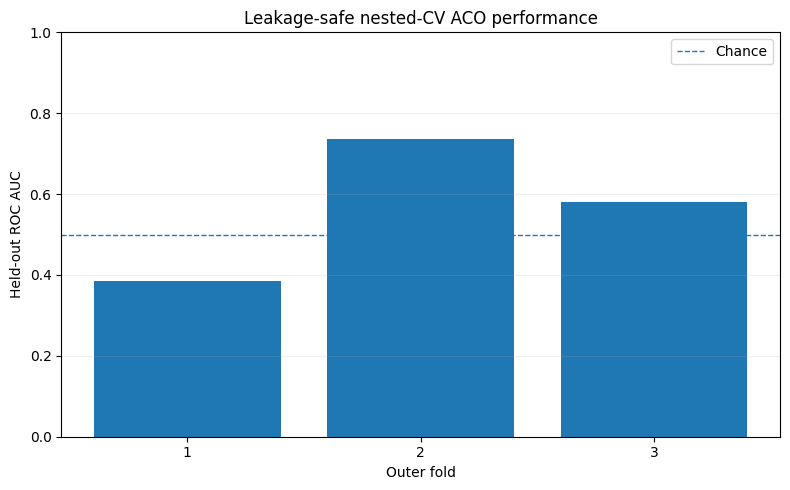

Saved: /kaggle/working/flux_aco/figures/nested_cv_fold_auc.png


In [19]:
if not nested_fold_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(
        nested_fold_df["outer_fold"].astype(str),
        nested_fold_df["test_auc"],
    )

    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1.0,
        label="Chance",
    )

    ax.set(
        title="Leakage-safe nested-CV ACO performance",
        xlabel="Outer fold",
        ylabel="Held-out ROC AUC",
        ylim=(0, 1),
    )

    ax.grid(axis="y", alpha=0.2)
    ax.legend()
    fig.tight_layout()

    nested_figure = FIGURE_ROOT / "nested_cv_fold_auc.png"

    fig.savefig(
        nested_figure,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print("Saved:", nested_figure)

## 20. Optional sensor-count curve

In [20]:
sensor_count_rows = []

if RUN_SENSOR_COUNT_CURVE:
    valid_counts = [
        count
        for count in SENSOR_COUNTS_TO_TEST
        if 1 <= count <= len(retained_sensor_names)
    ]

    for sensor_count in valid_counts:
        print("Sensor count:", sensor_count)

        result = run_aco(
            X_features,
            y,
            retained_sensor_names,
            sensor_feature_columns,
            full_heuristic,
            full_redundancy,
            sensor_count,
            COUNT_CURVE_ANTS,
            COUNT_CURVE_ITERATIONS,
            INNER_SPLITS,
            RANDOM_STATE + 5000 + sensor_count,
        )

        sensor_count_rows.append(
            {
                "n_physical_sensors": sensor_count,
                "best_inner_cv_auc": result.best_auc,
                "best_fitness": result.best_fitness,
                "mean_redundancy": result.best_redundancy,
                "selected_sensors": "|".join(result.best_subset),
            }
        )

    sensor_count_df = pd.DataFrame(sensor_count_rows)
    display(sensor_count_df)

    sensor_count_df.to_csv(
        REPORT_ROOT / "aco_sensor_count_curve.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        sensor_count_df["n_physical_sensors"],
        sensor_count_df["best_inner_cv_auc"],
        marker="o",
    )

    ax.axhline(0.5, linestyle="--", linewidth=1.0)

    ax.set(
        title="ACO performance versus physical-sensor count",
        xlabel="Number of physical sensors",
        ylabel="Best inner-CV ROC AUC",
    )
    ax.grid(alpha=0.2)
    fig.tight_layout()

    count_figure = FIGURE_ROOT / "aco_sensor_count_curve.png"

    fig.savefig(
        count_figure,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

else:
    sensor_count_df = pd.DataFrame()
    print(
        "Sensor-count curve disabled. "
        "Set RUN_SENSOR_COUNT_CURVE=True to run it."
    )

Sensor-count curve disabled. Set RUN_SENSOR_COUNT_CURVE=True to run it.


## 21. Exploratory time-resolved decoding with consensus sensors

Exploratory peak: AUC=0.7219 time=0.721 s


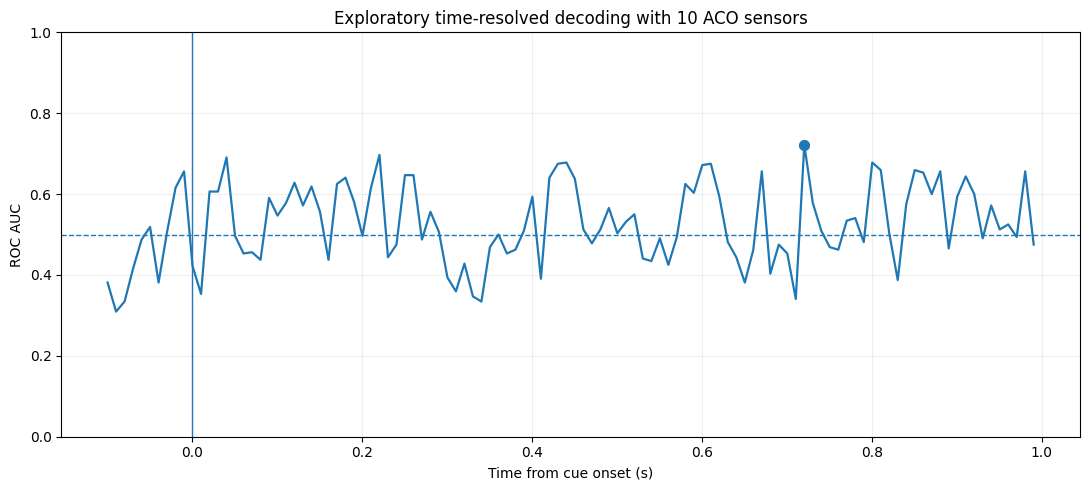

In [21]:
time_resolved_df = pd.DataFrame()

if RUN_TIME_RESOLVED_DECODING:
    consensus_channels = []

    for sensor_name in consensus_sensor_subset:
        consensus_channels.extend(
            [
                channel
                for channel in sensor_to_channels[sensor_name]
                if channel in signal_channel_names
            ]
        )

    consensus_channel_indices = [
        signal_channel_names.index(channel)
        for channel in consensus_channels
    ]

    time_mask = (
        (signal_times >= TIME_DECODING_TMIN_S)
        & (signal_times <= TIME_DECODING_TMAX_S)
    )

    decoding_times = signal_times[time_mask]

    X_time = X_signal[
        :,
        consensus_channel_indices,
        :,
    ][:, :, time_mask]

    effective_splits = min(
        TIME_DECODING_CV_SPLITS,
        int(np.min(np.bincount(y))),
    )

    time_cv = StratifiedKFold(
        n_splits=effective_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    time_cv_splits = list(time_cv.split(X_time, y))
    time_auc = []

    for time_index in range(X_time.shape[2]):
        scores = cross_val_score(
            make_classifier(),
            X_time[:, :, time_index],
            y,
            cv=time_cv_splits,
            scoring="roc_auc",
            n_jobs=INNER_N_JOBS,
        )
        time_auc.append(float(np.mean(scores)))

    time_resolved_df = pd.DataFrame(
        {
            "time_s": decoding_times,
            "mean_auc": time_auc,
        }
    )

    peak_row = time_resolved_df.iloc[
        int(np.argmax(time_resolved_df["mean_auc"].to_numpy()))
    ]

    print(
        "Exploratory peak:",
        f"AUC={peak_row['mean_auc']:.4f}",
        f"time={peak_row['time_s']:.3f} s",
    )

    time_resolved_df.to_csv(
        REPORT_ROOT / "consensus_sensor_time_resolved_auc.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(
        time_resolved_df["time_s"],
        time_resolved_df["mean_auc"],
        linewidth=1.6,
    )

    ax.axhline(0.5, linestyle="--", linewidth=1.0)
    ax.axvline(0.0, linewidth=1.0)

    ax.scatter(
        [peak_row["time_s"]],
        [peak_row["mean_auc"]],
        s=50,
    )

    ax.set(
        title=(
            f"Exploratory time-resolved decoding with "
            f"{TARGET_SENSOR_COUNT} ACO sensors"
        ),
        xlabel="Time from cue onset (s)",
        ylabel="ROC AUC",
        ylim=(0, 1),
    )

    ax.grid(alpha=0.2)
    fig.tight_layout()

    time_figure = (
        FIGURE_ROOT
        / "consensus_sensor_time_resolved_auc.png"
    )

    fig.savefig(
        time_figure,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

else:
    print("Time-resolved decoding is disabled.")

The time-resolved curve is exploratory because the consensus sensor list was selected using all trials.

## 22. Time-resolved energy of leading sensors

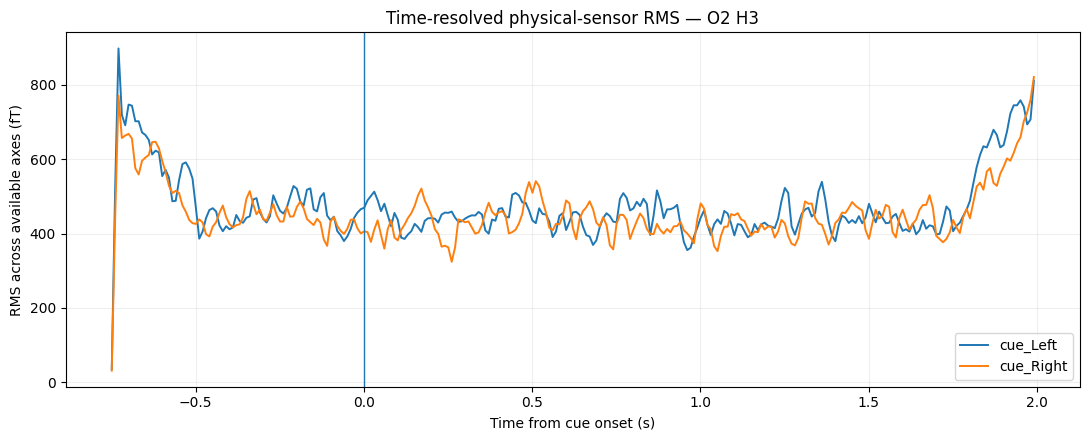

Saved: /kaggle/working/flux_aco/figures/energy_O2_H3.png


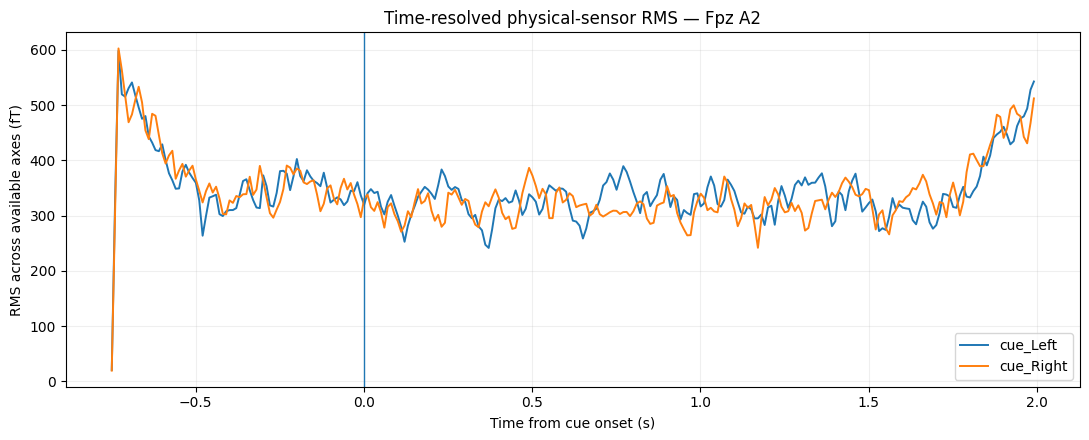

Saved: /kaggle/working/flux_aco/figures/energy_Fpz_A2.png


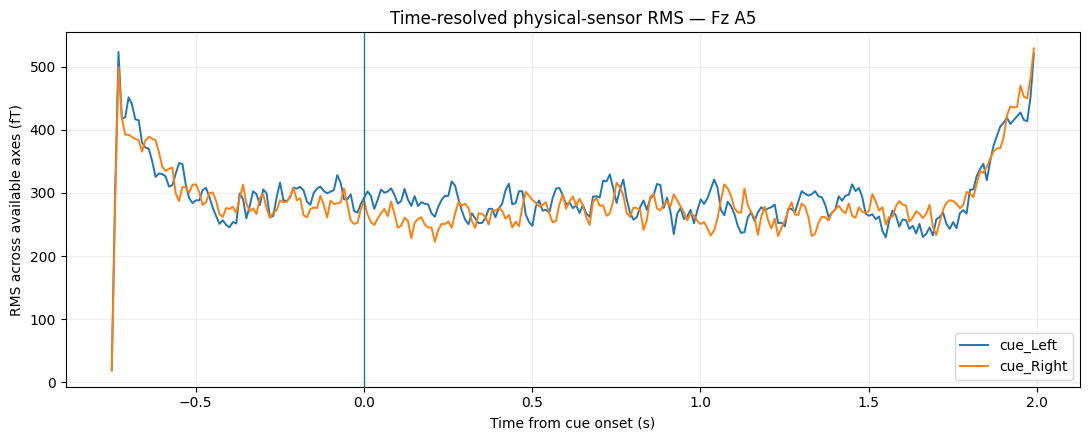

Saved: /kaggle/working/flux_aco/figures/energy_Fz_A5.png


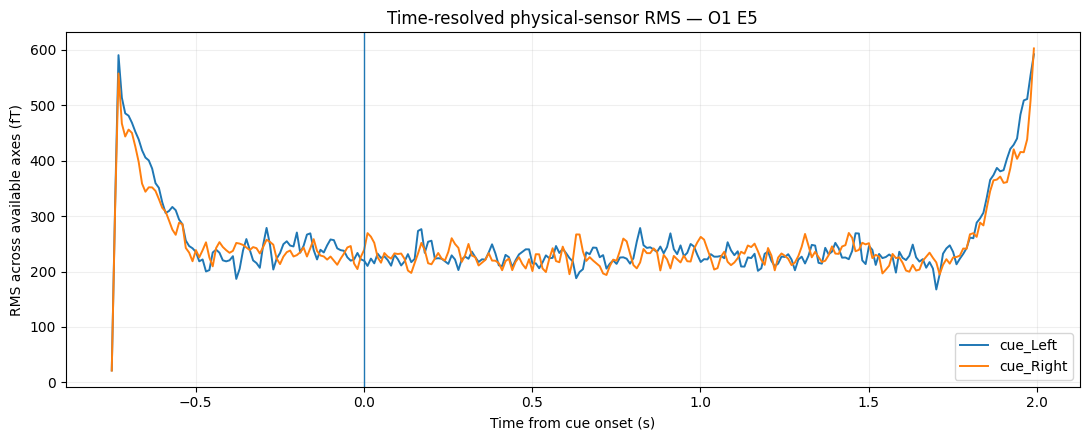

Saved: /kaggle/working/flux_aco/figures/energy_O1_E5.png


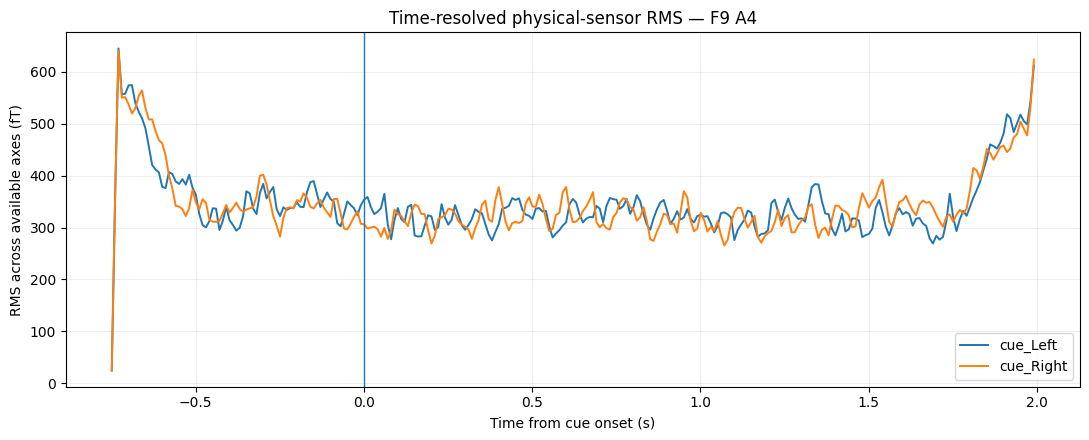

Saved: /kaggle/working/flux_aco/figures/energy_F9_A4.png


In [22]:
leading_energy_sensors = list(
    consensus_sensor_subset[:TOP_SENSORS_FOR_ENERGY_PLOTS]
)

for sensor_name in leading_energy_sensors:
    indices = [
        signal_channel_names.index(channel)
        for channel in sensor_to_channels[sensor_name]
        if channel in signal_channel_names
    ]

    sensor_signal = X_signal[:, indices, :]

    sensor_energy = np.sqrt(
        np.mean(sensor_signal**2, axis=1)
    ) * 1e15

    left_mean = np.mean(sensor_energy[y == 0], axis=0)
    right_mean = np.mean(sensor_energy[y == 1], axis=0)

    fig, ax = plt.subplots(figsize=(11, 4.5))

    ax.plot(
        signal_times,
        left_mean,
        linewidth=1.4,
        label="cue_Left",
    )

    ax.plot(
        signal_times,
        right_mean,
        linewidth=1.4,
        label="cue_Right",
    )

    ax.axvline(0.0, linewidth=1.0)

    ax.set(
        title=f"Time-resolved physical-sensor RMS — {sensor_name}",
        xlabel="Time from cue onset (s)",
        ylabel="RMS across available axes (fT)",
    )

    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()

    safe_name = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        sensor_name,
    ).strip("_")

    output = FIGURE_ROOT / f"energy_{safe_name}.png"

    fig.savefig(
        output,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print("Saved:", output)

## 23. Fit and save final consensus classifier

In [23]:
final_consensus_model = make_classifier()

final_consensus_model.fit(
    X_features[:, consensus_columns],
    y,
)

model_path = (
    MODEL_ROOT
    / (
        f"sub-{SUBJECT}_ses-{SESSION}_task-{TASK}_run-{RUN}_"
        f"desc-aco-{TARGET_SENSOR_COUNT}sensor-linear-svm.joblib"
    )
)

joblib.dump(
    {
        "model": final_consensus_model,
        "physical_sensors": list(consensus_sensor_subset),
        "sensor_to_channels": {
            sensor_name: sensor_to_channels[sensor_name]
            for sensor_name in consensus_sensor_subset
        },
        "feature_columns": consensus_columns,
        "feature_names": [
            feature_names[index]
            for index in consensus_columns
        ],
        "filter_hz": [
            FILTER_L_FREQ_HZ,
            FILTER_H_FREQ_HZ,
        ],
        "resample_hz": RESAMPLE_HZ,
        "feature_window_s": [
            FEATURE_TMIN_S,
            FEATURE_TMAX_S,
        ],
        "n_time_windows": N_TIME_WINDOWS,
        "class_mapping": {
            0: "cue_Left",
            1: "cue_Right",
        },
        "warning": (
            "Model fitted after full-data exploratory sensor selection. "
            "Use nested-CV metrics for generalisation reporting."
        ),
    },
    model_path,
)

print("Saved:", model_path)

Saved: /kaggle/working/flux_aco/models/sub-01_ses-01_task-SpAtt_run-01_desc-aco-10sensor-linear-svm.joblib


## 24. Save summary

In [25]:
nested_summary_records = (
    []
    if nested_summary_df.empty
    else nested_summary_df.to_dict(orient="records")
)

summary = {
    "input_epochs_file": str(EPOCHS_FILE),
    "quick_mode": bool(QUICK_MODE),
    "class_counts": {
        "cue_Left": int(np.sum(y == 0)),
        "cue_Right": int(np.sum(y == 1)),
    },
    "physical_sensors": {
        "discovered": int(len(sensor_inventory_df)),
        "retained": int(len(retained_sensor_names)),
        "require_complete_xyz": bool(REQUIRE_COMPLETE_XYZ),
    },
    "feature_matrix_shape": list(X_features.shape),
    "aco": {
        "target_sensor_count": int(TARGET_SENSOR_COUNT),
        "ants": int(ACO_ANTS),
        "iterations": int(ACO_ITERATIONS),
        "runs": int(ACO_RUNS),
        "alpha": float(ACO_ALPHA),
        "beta": float(ACO_BETA),
        "evaporation": float(ACO_EVAPORATION),
        "redundancy_weight": float(REDUNDANCY_WEIGHT),
        "consensus_sensors": list(consensus_sensor_subset),
        "mean_run_best_auc": float(full_run_df["best_auc"].mean()),
        "std_run_best_auc": float(
            full_run_df["best_auc"].std(ddof=1)
            if len(full_run_df) > 1
            else 0.0
        ),
    },
    "exploratory_consensus_evaluation": (
        exploratory_comparison_df.to_dict(orient="records")
    ),
    "nested_cv": nested_summary_records,
    "sensor_count_curve_run": bool(RUN_SENSOR_COUNT_CURVE),
    "time_resolved_decoding_run": bool(
        RUN_TIME_RESOLVED_DECODING
    ),
    "model_file": str(model_path),
    "figures": sorted(
        str(path.relative_to(WORK_ROOT))
        for path in FIGURE_ROOT.glob("*")
        if path.is_file()
    ),
    "reports": sorted(
        str(path.relative_to(WORK_ROOT))
        for path in REPORT_ROOT.glob("*")
        if path.is_file()
    ),
}

summary_path = REPORT_ROOT / "aco_sensor_selection_summary.json"

summary_path.write_text(
    json.dumps(summary, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Saved:", summary_path)

Saved: /kaggle/working/flux_aco/reports/aco_sensor_selection_summary.json


## 25. Zip 

In [26]:
figures_zip = shutil.make_archive(
    "/kaggle/working/FLUX_ACO_figures",
    "zip",
    root_dir=FIGURE_ROOT,
)

reports_zip = shutil.make_archive(
    "/kaggle/working/FLUX_ACO_reports",
    "zip",
    root_dir=REPORT_ROOT,
)

models_zip = shutil.make_archive(
    "/kaggle/working/FLUX_ACO_models",
    "zip",
    root_dir=MODEL_ROOT,
)

print("Figures ZIP:", figures_zip)
print("Reports ZIP:", reports_zip)
print("Models ZIP:", models_zip)

if CREATE_DERIVATIVE_ZIP:
    derivative_zip = shutil.make_archive(
        "/kaggle/working/FLUX_ACO_derivatives",
        "zip",
        root_dir=DERIV_ROOT,
    )
    print("Derivatives ZIP:", derivative_zip)
else:
    print(
        "Derivative ZIP disabled. Use Save Version → Save output."
    )

Figures ZIP: /kaggle/working/FLUX_ACO_figures.zip
Reports ZIP: /kaggle/working/FLUX_ACO_reports.zip
Models ZIP: /kaggle/working/FLUX_ACO_models.zip
Derivative ZIP disabled. Use Save Version → Save output.
